# 06 - Scaling: DDM vs. Transformer at Three Sizes[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/yaso09/ddm/blob/master/notebooks/06_Scaling.ipynb)
**Summary.** Trains DDM and the Transformer baseline at three model sizes(`configs/scaling_small.yaml`, `configs/scaling_medium.yaml`, `configs/scaling_large.yaml`)on the same data and plots test perplexity against parameter count(log-log). The question: does DDM's advantage hold as the model grows?Set `DDM_SMOKE=1` for a quick smoke run.

In [ ]:
# --- Colab / Kaggle setup: clone the DDM repo and expose the package ---
import os, subprocess, sys
from pathlib import Path

REPO_URL = "https://github.com/yaso09/ddm.git"

def _find_repo_root() -> Path | None:
    here = Path.cwd()
    for cand in [here, here.parent, here.parent.parent]:
        if (cand / "configs").is_dir() and (cand / "src" / "ddm").is_dir():
            return cand
    return None

ROOT = _find_repo_root()
if ROOT is None:
    # Fresh cloud environment (Colab/Kaggle): clone the repository.
    print("[setup] cloning DDM repository ...")
    subprocess.run(["git", "clone", "--depth", "1", REPO_URL, "ddm"], check=True)
    ROOT = Path.cwd() / "ddm"

os.chdir(ROOT)
# The package lives under src/; add it so `import ddm` works.
sys.path.insert(0, str(ROOT / "src"))
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print("repo root:", ROOT)


In [1]:
# --- repo root bootstrap: lets the notebook run from any working directory ---
import os, sys
from pathlib import Path

def _find_root() -> Path:
    here = Path.cwd()
    for cand in [here, here.parent, here.parent.parent]:
        if (cand / "configs").is_dir() and (cand / "src" / "ddm").is_dir():
            return cand
    return here

ROOT = _find_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
os.chdir(ROOT)
SMOKE = os.environ.get("DDM_SMOKE", "0") == "1"
print("repo root:", ROOT, "| DDM_SMOKE:", SMOKE)


repo root: C:\Users\yasir\Desktop\ammar | DDM_SMOKE: True


In [2]:
from pathlib import Path

from ddm.config import DDMConfig
from ddm.train import run_training
from ddm.models import count_parameters, build_model
import matplotlib.pyplot as plt

%matplotlib inline

In [3]:
SIZES = ["small", "medium", "large"]
results = {}

for size in SIZES:
    base = DDMConfig.from_yaml(f"configs/scaling_{size}.yaml")
    for model_type in ("ddm", "transformer"):
        cfg = DDMConfig(**base.__dict__)
        cfg.model_type = model_type
        if SMOKE:
            cfg.max_steps = 3
            cfg.max_blocks = 64
            cfg.epochs = 1
        print(f"\n################ {model_type} ({size}) ################")
        res = run_training(cfg)
        res["n_params"] = count_parameters(build_model(cfg))
        results[(model_type, size)] = res


################ ddm (small) ################
[train] device: cuda
[data] loading wikitext/wikitext-2-raw-v1 (cache: hf_cache)...


[data] script-based loading failed (HfUriError: Invalid HF URI 'hf://datasets/wikitext@b08601e04326c79dfdd32d625aee71d232d685c3/.huggingface.yaml'. Repository id must be 'namespace/name', got 'wikitext'.); switching to local parquet fallback...


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (2391884 > 1024). Running this sequence through the model will result in indexing errors


[data] blocks -> train: (64, 128), val: (64, 128), test: (64, 128)
[train] vocab_size: 50257

=== seed 0 ===


[train] ddm parameters: 6,583,347


...

[data] script-based loading failed (HfUriError: Invalid HF URI 'hf://datasets/wikitext@b08601e04326c79dfdd32d625aee71d232d685c3/.huggingface.yaml'. Repository id must be 'namespace/name', got 'wikitext'.); switching to local parquet fallback...


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (2391884 > 1024). Running this sequence through the model will result in indexing errors


[data] blocks -> train: (64, 128), val: (64, 128), test: (64, 128)
[train] vocab_size: 50257

=== seed 0 ===
[train] transformer parameters: 27,394,641
--- epoch 1/1 ---


[train] epoch 1: loss 10.9677, val PPL 52588.68


[train] test PPL: 51979.92 (3.0s)


### Parameter count vs. test PPL

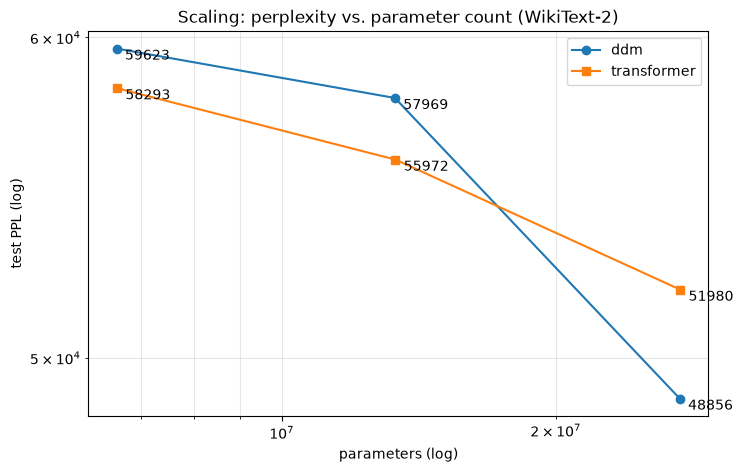

In [4]:
plt.figure(figsize=(8, 5))
for model_type, color, marker in (("ddm", "tab:blue", "o"), ("transformer", "tab:orange", "s")):
    pts = [(results[(model_type, s)]["n_params"], results[(model_type, s)]["test_ppl_mean"])
           for s in SIZES]
    x, y = zip(*pts, strict=True)
    plt.plot(x, y, marker=marker, color=color, label=model_type)
    for xi, yi in zip(x, y, strict=True):
        plt.annotate(f"{yi:.0f}", (xi, yi), textcoords="offset points", xytext=(6, -8))
plt.xscale("log"); plt.yscale("log")
plt.xlabel("parameters (log)"); plt.ylabel("test PPL (log)")
plt.title("Scaling: perplexity vs. parameter count (WikiText-2)")
plt.grid(alpha=0.3, which="both"); plt.legend(); plt.show()

In [5]:
rows = ["| Size | Model | Params | Test PPL |", "|---|---|---|---|"]
for size in SIZES:
    for model_type in ("ddm", "transformer"):
        r = results[(model_type, size)]
        rows.append(f"| {size} | {model_type} | {r['n_params']:,} | {r['test_ppl_mean']:.2f} |")
table = "\n".join(rows) + "\n"
print(table)
out = Path("checkpoints") / "scaling_results.md"
out.write_text(table, encoding="utf-8")
print("written to", out)

| Size | Model | Params | Test PPL |
|---|---|---|---|
| small | ddm | 6,583,347 | 59623.26 |
| small | transformer | 6,591,441 | 58293.22 |
| medium | ddm | 13,312,947 | 57969.15 |
| medium | transformer | 13,329,233 | 55972.18 |
| large | ddm | 27,361,971 | 48855.85 |
| large | transformer | 27,394,641 | 51979.92 |

written to checkpoints\scaling_results.md


### Discussion

- **Slope of the log-log line**: a steep drop in PPL per doubling of
  parameters means the architecture scales well on this budget.
- **Gap behaviour**: if DDM stays below the transformer at all three sizes,
  the distance-aware inductive bias transfers to larger models; if the gap
  shrinks, the absolute-position transformer catches up as capacity grows.
- Caveats: small data (WikiText-2), few epochs, no learning-rate tuning per
  size - treat this as a trend analysis, not a scaling law.